In [26]:
import lasio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils import resample
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, DBSCAN
from scipy.interpolate import interp1d

pd.set_option('display.max_columns', None)


In [82]:
df_xrd=pd.read_csv("56-32 XRD Results_v2.csv")

In [83]:
df_xrd.rename(columns={"Unnamed: 0":"From (ft)",
                      "Unnamed: 1":"To (ft)"}, inplace=True)

In [84]:
df_xrd.describe().T

,count,mean,std,min,25%,50%,75%,max
From (ft),69.0,6095.797101,1891.868362,3050.0,4400.00,6100.0,7800.00,9120.0
To (ft),69.0,6105.797101,1891.868362,3060.0,4410.00,6110.0,7810.00,9130.0
Quartz,69.0,15.115942,13.873945,1.0,4.00,12.0,21.00,80.0
Plagioclase,69.0,44.362319,14.750843,0.0,38.00,48.0,53.00,69.0
K-feldspar,69.0,22.057971,13.195235,0.0,7.00,27.0,32.00,44.0
Epidote,2.0,4.500000,0.707107,4.0,4.25,4.5,4.75,5.0
kaolinite,4.0,5.000000,1.825742,3.0,3.75,5.0,6.25,7.0
Diopside,7.0,10.285714,9.123491,1.0,2.50,9.0,16.50,24.0


In [85]:
df_xrd = df_xrd.rename(columns={'Unnamed: 0': 'From (ft)', 'Unnamed: 1': 'To (ft)'})

# Re-run the linearization with corrected column names
expanded_rows = []

for _, row in df_xrd.iterrows():
    for depth in range(int(row['From (ft)']), int(row['To (ft)'])):
        new_row = row.drop(labels=['From (ft)', 'To (ft)']).to_dict()
        new_row['Depth (ft)'] = depth
        expanded_rows.append(new_row)

df_xrd_linear = pd.DataFrame(expanded_rows)

In [3]:
las=lasio.read("University_of_Utah_Forge_56_32_ThrubitDipole_Aniso_analysis_result_3452-9050ft_LAS.las")
df_wireline=las.df()

In [28]:
df_wireline.head()

,AZIM,BS_RM,C1_24,DEVI,DTCO_MPS_R,DTSH_FAST,DTSH_SLOW,FSA_ERRMINUS,FSA_ERRPLUS,FSA_NAZ_IN,FSA_TOH,GR_TMG,MAXXENE_OVERALL,MINXENE_OVERALL,PR_FAST,RB,SENSOR_AZIM_QCI,SLOANI,SPHI,TDIF_ALT_OVERALL,TDIF_ORG_OVERALL,TIMANI,TNPH,TW_B_L6,TW_E_L6,VPVS_FAST,XENEDIF,MD
MD,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3452.0,0.0,8.75,8.9774,2.8034,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.2895,NaN,NaN,NaN,312.53,NaN,NaN,NaN,NaN,NaN,NaN,0.1263,998.7773,1998.7773,NaN,NaN,3452.0
3452.5,0.0,8.75,8.9726,2.6300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.1914,NaN,NaN,NaN,312.53,NaN,NaN,NaN,NaN,NaN,NaN,0.1341,998.7773,1998.7773,NaN,NaN,3452.5
3453.0,0.0,8.75,8.9669,2.7123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.4440,NaN,NaN,NaN,311.87,NaN,NaN,NaN,NaN,NaN,NaN,0.1384,998.7773,1998.7773,NaN,NaN,3453.0
3453.5,0.0,8.75,8.9632,2.7898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.8437,NaN,NaN,NaN,311.87,NaN,NaN,NaN,NaN,NaN,NaN,0.1456,998.7773,1998.7773,NaN,NaN,3453.5
3454.0,0.0,8.75,8.9603,2.8729,52.7234,98.3777,99.3549,NaN,NaN,NaN,NaN,84.7917,NaN,NaN,0.2985,311.96,NaN,0.9884,0.0362,NaN,NaN,NaN,0.1558,998.7773,1998.7773,1.8659,NaN,3454.0


Modelling with KMEANS

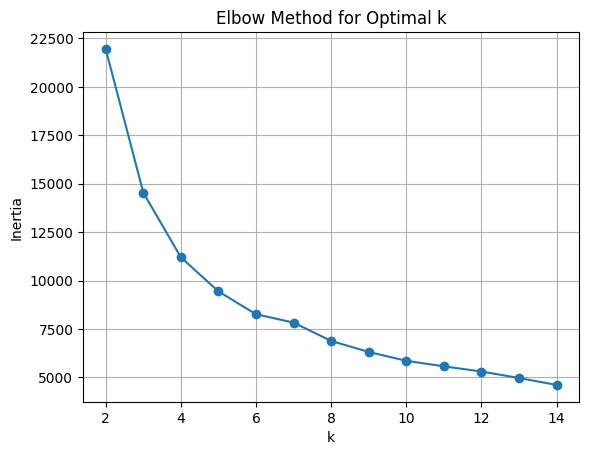

CPU times: user 578 ms, sys: 368 ms, total: 946 ms
Wall time: 162 ms


In [30]:
%%time
inertias = []
k_values = range(2, 15)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)  # use same scaler from previous step
    inertias.append(model.inertia_)

plt.plot(k_values, inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

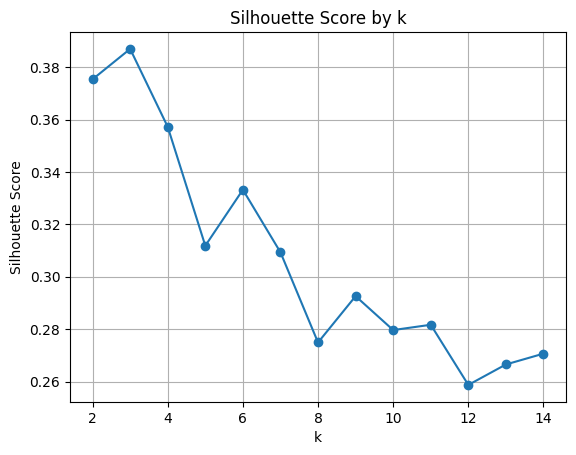

In [31]:
from sklearn.metrics import silhouette_score

scores = []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.plot(k_values, scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k')
plt.grid(True)
plt.show()


In [42]:
print("k_values:", list(k_values))
print("inertias:",inertias)
print("silhouette score:",scores)

k_values: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
inertias: [21960.960358211596, 14541.808212083059, 11200.55101936771, 9438.412234014675, 8260.341843038137, 7826.391146246654, 6880.111769839987, 6312.58707060539, 5854.628359783492, 5569.274963126356, 5301.8378222779265, 4965.978739328407, 4609.2619102464905]
silhouette score: [np.float64(0.3753451331982342), np.float64(0.3869355516924749), np.float64(0.35720193518247145), np.float64(0.3118408489159171), np.float64(0.3332098990080697), np.float64(0.3093526298055704), np.float64(0.2749347363664551), np.float64(0.2926056369979913), np.float64(0.2796721272566249), np.float64(0.2816917913373457), np.float64(0.2587416057441898), np.float64(0.266550098905568), np.float64(0.2706774545639412)]


In [43]:
def perform_kmeans_clustering(df, features, n_clusters=3):
    """
    Perform KMeans clustering on selected features of a DataFrame.

    Parameters:
    - df: pandas DataFrame containing the data
    - features: list of column names to use for clustering
    - n_clusters: number of clusters to form

    Returns:
    - df_clustered: DataFrame with cluster labels added
    - model: fitted KMeans model
    - scaler: fitted StandardScaler
    """
    # Step 1: Drop rows with NaNs in selected features
    df_clustered = df[['MD'] + features].dropna().copy()

    # Step 2: Standardize the selected features
    X = df_clustered[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Step 3: Apply KMeans clustering
    model = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = model.fit_predict(X_scaled)

    # Step 4: Attach cluster labels to DataFrame
    df_clustered['Cluster'] = cluster_labels

    return df_clustered, model, scaler

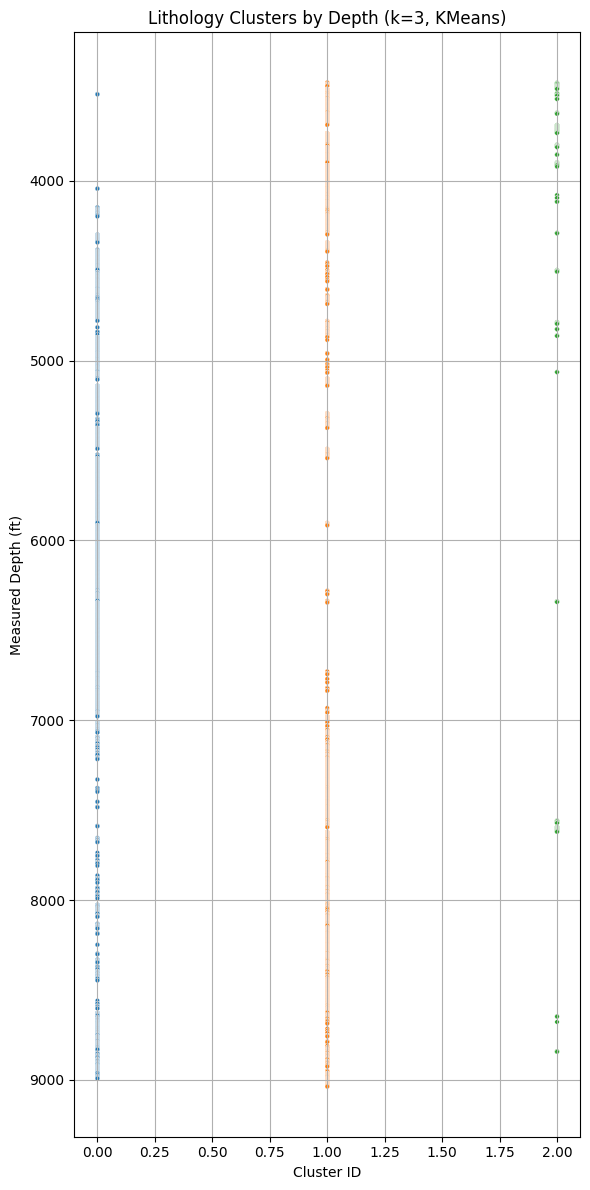

In [59]:
df_kmeans_3, kmeans_model_3, scaler_3 = perform_kmeans_clustering(
    df=df_wireline,
    features=['GR_TMG', 'DTCO_MPS_R', 'TNPH'],
    n_clusters=3
)

# Plot clusters over depth
plt.figure(figsize=(6, 12))
sns.scatterplot(
    data=df_kmeans_3,
    x='Cluster',
    y='MD',
    hue='Cluster',
    palette='tab10',
    s=10,
    legend=False
)
plt.gca().invert_yaxis()
plt.title("Lithology Clusters by Depth (k=3, KMeans)")
plt.xlabel("Cluster ID")
plt.ylabel("Measured Depth (ft)")
plt.grid(True)
plt.tight_layout()
plt.show()


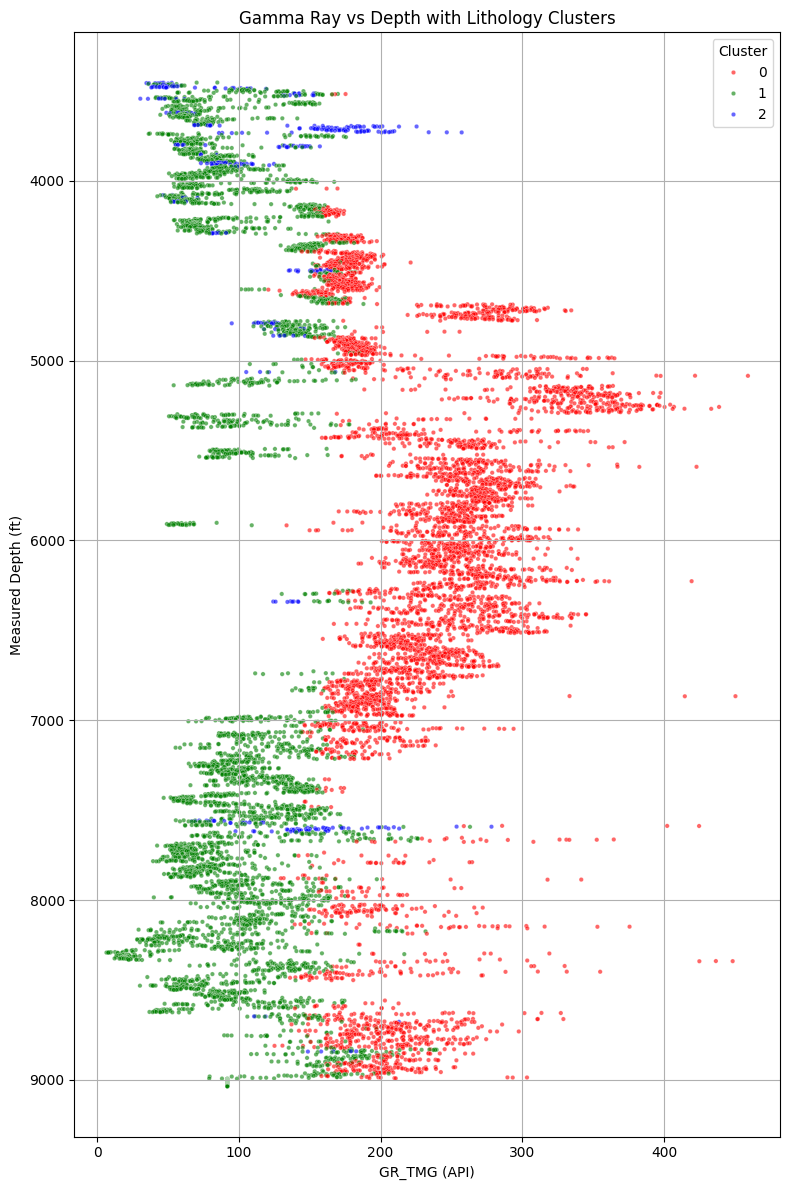

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'MD', 'GR_TMG', and 'Cluster' columns exist in df_kmeans_3
plt.figure(figsize=(8, 12))

# Set a color palette for the clusters
palette = {0: 'red', 1: 'green', 2: 'blue'}

# Plot GR_TMG vs Depth, colored by cluster
sns.scatterplot(
    data=df_kmeans_3,
    x='GR_TMG',
    y='MD',
    hue='Cluster',
    palette=palette,
    s=10,  # point size
    alpha=0.6
)

plt.gca().invert_yaxis()  # Depth increases downward
plt.xlabel("GR_TMG (API)")
plt.ylabel("Measured Depth (ft)")
plt.title("Gamma Ray vs Depth with Lithology Clusters")
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


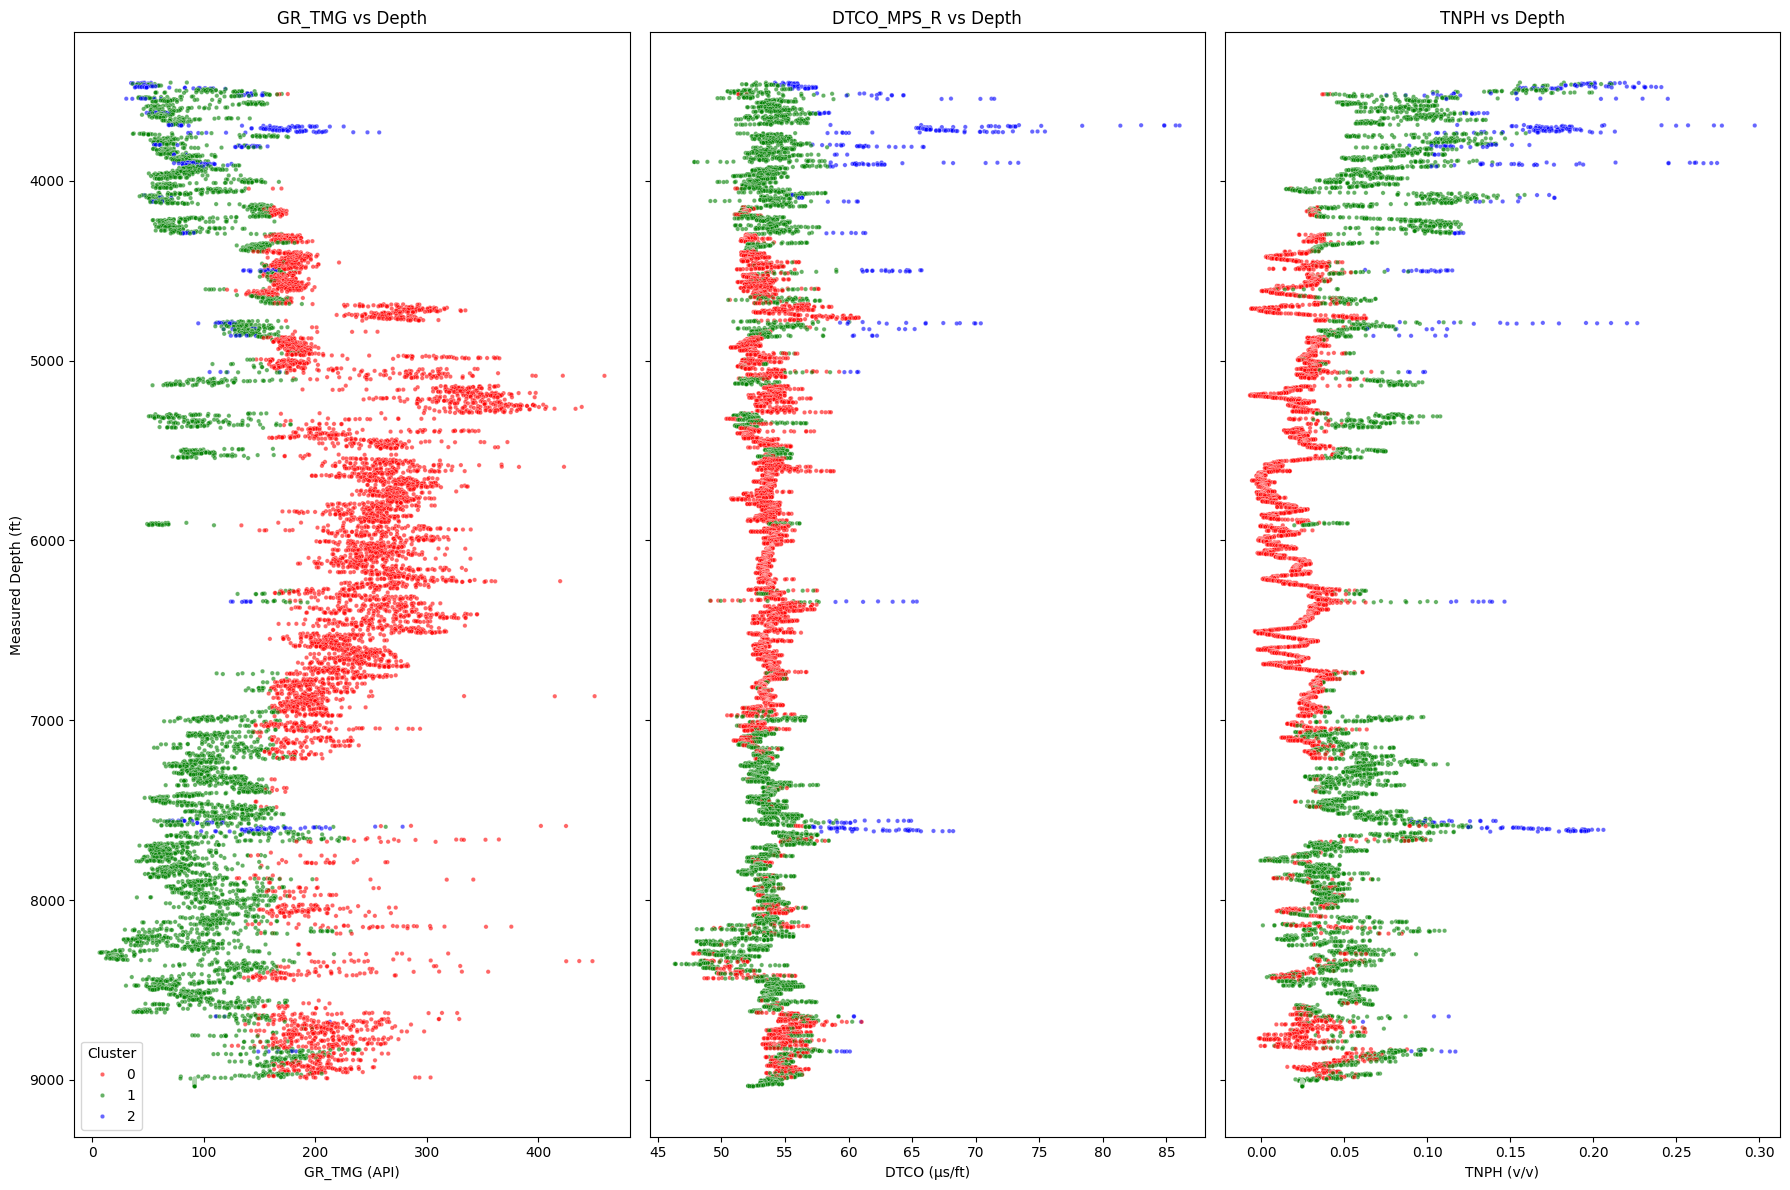

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sample structure creation for demonstration (since df_kmeans_3 not accessible directly)
# You would replace this with your actual df_kmeans_3 DataFrame
# df_kmeans_3 = pd.read_csv("your_data.csv")  # Example of loading actual data if needed

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 12), sharey=True)

# Define color palette
palette = {0: 'red', 1: 'green', 2: 'blue'}

# GR_TMG vs Depth
sns.scatterplot(
    data=df_kmeans_3,
    x='GR_TMG',
    y='MD',
    hue='Cluster',
    palette=palette,
    s=10,
    alpha=0.6,
    ax=axes[0]
)
axes[0].invert_yaxis()
axes[0].set_xlabel("GR_TMG (API)")
axes[0].set_ylabel("Measured Depth (ft)")
axes[0].set_title("GR_TMG vs Depth")

# DTCO_MPS_R vs Depth
sns.scatterplot(
    data=df_kmeans_3,
    x='DTCO_MPS_R',
    y='MD',
    hue='Cluster',
    palette=palette,
    s=10,
    alpha=0.6,
    ax=axes[1]
)
axes[1].invert_yaxis()
axes[1].set_xlabel("DTCO (μs/ft)")
axes[1].set_title("DTCO_MPS_R vs Depth")

# TNPH vs Depth
sns.scatterplot(
    data=df_kmeans_3,
    x='TNPH',
    y='MD',
    hue='Cluster',
    palette=palette,
    s=10,
    alpha=0.6,
    ax=axes[2]
)
axes[2].invert_yaxis()
axes[2].set_xlabel("TNPH (v/v)")
axes[2].set_title("TNPH vs Depth")

# Adjust layout and remove duplicate legends
axes[1].get_legend().remove()
axes[2].get_legend().remove()
axes[0].legend(title="Cluster", loc="lower left")

plt.tight_layout()
plt.show()


<Axes: >

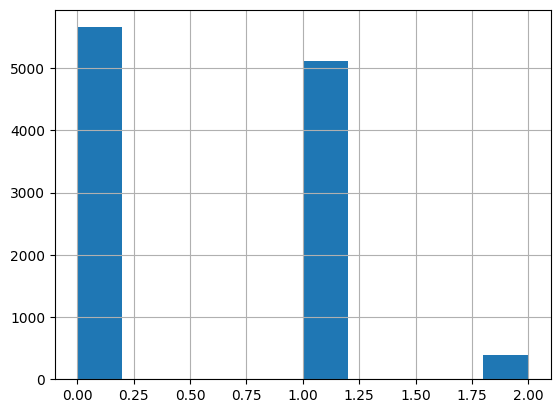

In [65]:
df_kmeans_3['Cluster'].hist()

In [46]:
df_kmeans_3.groupby('Cluster')[['GR_TMG', 'DTCO_MPS_R', 'TNPH']].describe().round(2)

GR_TMG                                                         \
          count    mean    std     min     25%     50%     75%     max   
Cluster                                                                  
0        5659.0  232.04  53.07  120.81  186.09  227.66  267.73  459.18   
1        5124.0  102.50  38.62    6.60   71.44   95.90  134.47  263.08   
2         383.0  123.13  49.42   30.46   82.54  132.06  157.88  278.24   

        DTCO_MPS_R                                                    TNPH  \
             count   mean   std    min    25%    50%    75%    max   count   
Cluster                                                                      
0           5659.0  53.68  1.37  47.76  52.92  53.61  54.28  61.03  5659.0   
1           5124.0  53.64  1.62  46.33  52.74  53.62  54.51  60.28  5124.0   
2            383.0  62.80  5.48  54.21  59.05  61.52  65.94  86.04   383.0   

                                                   
         mean   std   min   25%   50%   75%   max  
Cluster                                            
0        0.02  0.01 -0.01  0.01  0.02  0.03  0.10  
1        0.06  0.03 -0.00  0.04  0.05  0.07  0.21  
2        0.16  0.04  0.06  0.12  0.16  0.19  0.30

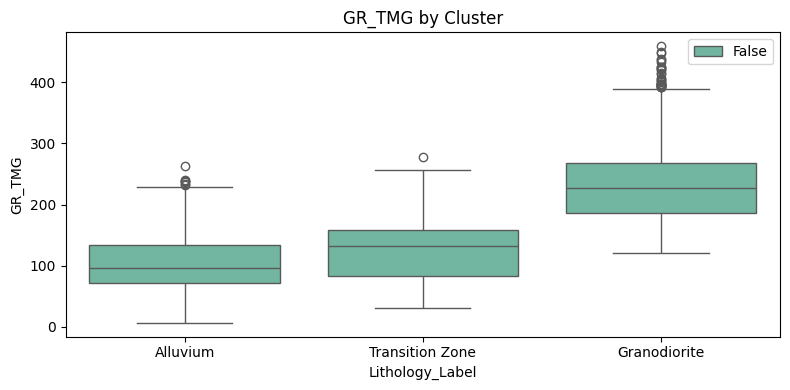

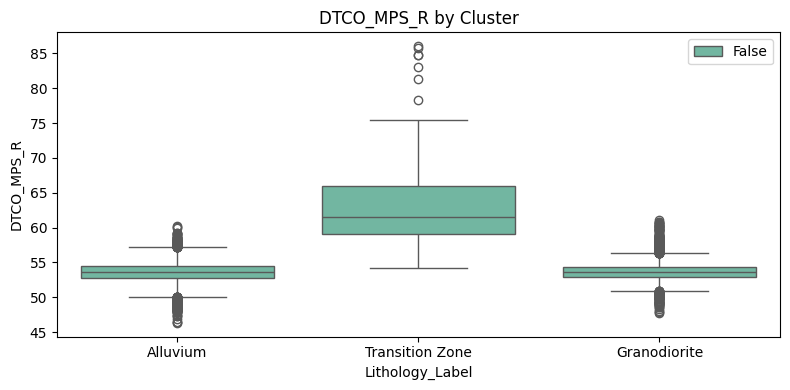

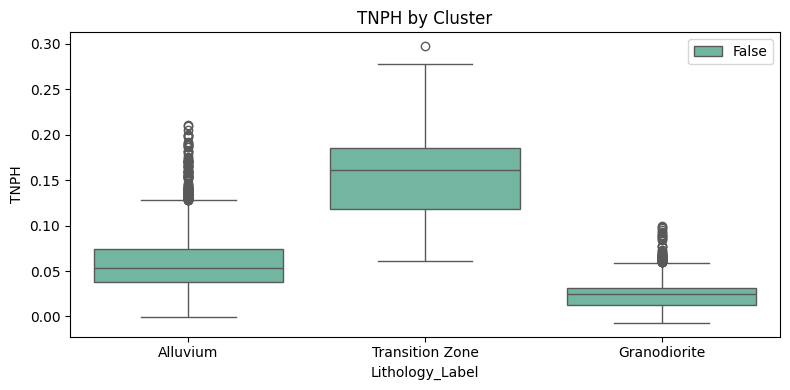

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['GR_TMG', 'DTCO_MPS_R', 'TNPH']
for feature in features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_kmeans_3, x='Lithology_Label', y=feature, hue=False, palette='Set2')
    plt.title(f"{feature} by Cluster")
    plt.tight_layout()
    plt.show()


In [49]:
cluster_to_litho = {
    0: 'Granodiorite',
    1: 'Alluvium',
    2: 'Transition Zone'
}

df_kmeans_3['Lithology_Label'] = df_kmeans_3['Cluster'].map(cluster_to_litho)


<Axes: >

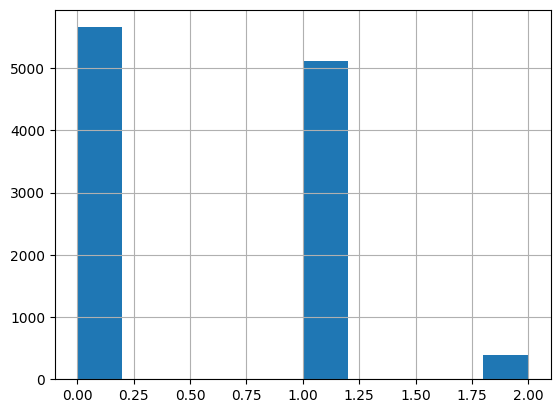

In [51]:
df_kmeans_3['Cluster'].hist()

In [57]:
# Pick the same features you used in the boxplots
features = ['GR_TMG', 'DTCO_MPS_R', 'TNPH']

# Compute summary statistics per cluster
summary_stats = df_kmeans_3.groupby('Cluster')[features].describe().round(2)

# View only means
cluster_means = df_kmeans_3.groupby('Cluster')[features].mean().round(2)
print("Cluster Means:\n", cluster_means)

# (Optional) View all summary stats
summary_stats


Cluster Means:
          GR_TMG  DTCO_MPS_R  TNPH
Cluster                          
0        232.04       53.68  0.02
1        102.50       53.64  0.06
2        123.13       62.80  0.16


GR_TMG                                                         \
          count    mean    std     min     25%     50%     75%     max   
Cluster                                                                  
0        5659.0  232.04  53.07  120.81  186.09  227.66  267.73  459.18   
1        5124.0  102.50  38.62    6.60   71.44   95.90  134.47  263.08   
2         383.0  123.13  49.42   30.46   82.54  132.06  157.88  278.24   

        DTCO_MPS_R                                                    TNPH  \
             count   mean   std    min    25%    50%    75%    max   count   
Cluster                                                                      
0           5659.0  53.68  1.37  47.76  52.92  53.61  54.28  61.03  5659.0   
1           5124.0  53.64  1.62  46.33  52.74  53.62  54.51  60.28  5124.0   
2            383.0  62.80  5.48  54.21  59.05  61.52  65.94  86.04   383.0   

                                                   
         mean   std   min   25%   50%   75%   max  
Cluster                                            
0        0.02  0.01 -0.01  0.01  0.02  0.03  0.10  
1        0.06  0.03 -0.00  0.04  0.05  0.07  0.21  
2        0.16  0.04  0.06  0.12  0.16  0.19  0.30

In [92]:
df_kmeans_3 = df_kmeans_3.reset_index(drop=True)

In [93]:
df_kmeans_3.head()

,MD,GR_TMG,DTCO_MPS_R,TNPH,Cluster
0,3454.0,84.7917,52.7234,0.1558,1
1,3454.5,70.2346,53.5003,0.1823,1
2,3455.0,46.8231,54.2051,0.2008,2
3,3455.5,52.6759,54.8287,0.2190,2
4,3456.0,44.8721,55.2530,0.2274,2


In [96]:
df_xrd_linear

,Quartz,Plagioclase,K-feldspar,Biotite,Hornblende,Clinopyroxene,Titanite,Magnetite,Anhydrite,Calcite,Siderite,Dolomite,Illite,chlorite,Muscovite,Epidote,kaolinite,Diopside,Scapolite,Depth (ft)
0,33,23,27,1,2,1,1,tr,NaN,tr,tr,2,4,tr,NaN,NaN,4.0,NaN,NaN,3050
1,33,23,27,1,2,1,1,tr,NaN,tr,tr,2,4,tr,NaN,NaN,4.0,NaN,NaN,3051
2,33,23,27,1,2,1,1,tr,NaN,tr,tr,2,4,tr,NaN,NaN,4.0,NaN,NaN,3052
3,33,23,27,1,2,1,1,tr,NaN,tr,tr,2,4,tr,NaN,NaN,4.0,NaN,NaN,3053
4,33,23,27,1,2,1,1,tr,NaN,tr,tr,2,4,tr,NaN,NaN,4.0,NaN,NaN,3054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,32,42,5,15,tr,NaN,NaN,NaN,NaN,tr,NaN,NaN,tr,4,NaN,NaN,NaN,NaN,NaN,9125
686,32,42,5,15,tr,NaN,NaN,NaN,NaN,tr,NaN,NaN,tr,4,NaN,NaN,NaN,NaN,NaN,9126
687,32,42,5,15,tr,NaN,NaN,NaN,NaN,tr,NaN,NaN,tr,4,NaN,NaN,NaN,NaN,NaN,9127
688,32,42,5,15,tr,NaN,NaN,NaN,NaN,tr,NaN,NaN,tr,4,NaN,NaN,NaN,NaN,NaN,9128


In [112]:
df_xrd_linear_sorted["Depth (ft)"]=df_xrd_linear_sorted["Depth (ft)"].astype('float64')

In [119]:
print(df_xrd_linear_sorted["Depth (ft)"].info())
print('\n')
print(df_kmeans_3_sorted['MD'].info())

<class 'pandas.core.series.Series'>
RangeIndex: 690 entries, 0 to 689
Series name: Depth (ft)
Non-Null Count  Dtype  
--------------  -----  
690 non-null    float64
dtypes: float64(1)
memory usage: 5.5 KB
None


<class 'pandas.core.series.Series'>
RangeIndex: 11166 entries, 0 to 11165
Series name: MD
Non-Null Count  Dtype  
--------------  -----  
11166 non-null  float64
dtypes: float64(1)
memory usage: 87.4 KB
None


In [124]:
df_kmeans_3_sorted

,MD,GR_TMG,DTCO_MPS_R,TNPH,Cluster
0,3454.0,84.7917,52.7234,0.1558,1
1,3454.5,70.2346,53.5003,0.1823,1
2,3455.0,46.8231,54.2051,0.2008,2
3,3455.5,52.6759,54.8287,0.2190,2
4,3456.0,44.8721,55.2530,0.2274,2
...,...,...,...,...,...
11161,9034.5,91.8452,52.1909,0.0246,1
11162,9035.0,91.8452,52.1889,0.0246,1
11163,9035.5,91.8452,52.3371,0.0246,1
11164,9036.0,91.8452,52.5074,0.0246,1


In [120]:
# Make sure both DataFrames are sorted
df_kmeans_3_sorted = df_kmeans_3.sort_values("MD")
df_xrd_linear_sorted = df_xrd_linear.sort_values("Depth (ft)")

# Perform depth-based nearest merge
df_cluster_with_xrd = pd.merge_asof(
    df_kmeans_3_sorted,
    df_xrd_linear_sorted,
    left_on="MD",
    right_on="Depth (ft",
    direction="nearest"
)

KeyError: 'Requested level (Depth (ft) does not match index name (None)'

In [109]:
df_kmeans_3_sorted["MD"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 11166 entries, 0 to 11165
Series name: MD
Non-Null Count  Dtype  
--------------  -----  
11166 non-null  float64
dtypes: float64(1)
memory usage: 87.4 KB


In [110]:
df_xrd_linear_sorted["Depth (ft)"].info()


<class 'pandas.core.series.Series'>
RangeIndex: 690 entries, 0 to 689
Series name: Depth (ft)
Non-Null Count  Dtype
--------------  -----
690 non-null    int64
dtypes: int64(1)
memory usage: 5.5 KB
